FIELD TEST PREDICTION: TOPOLOGICAL DECOHERENCE SCALING

✓ Saved: field_test_prediction_alpha2.png


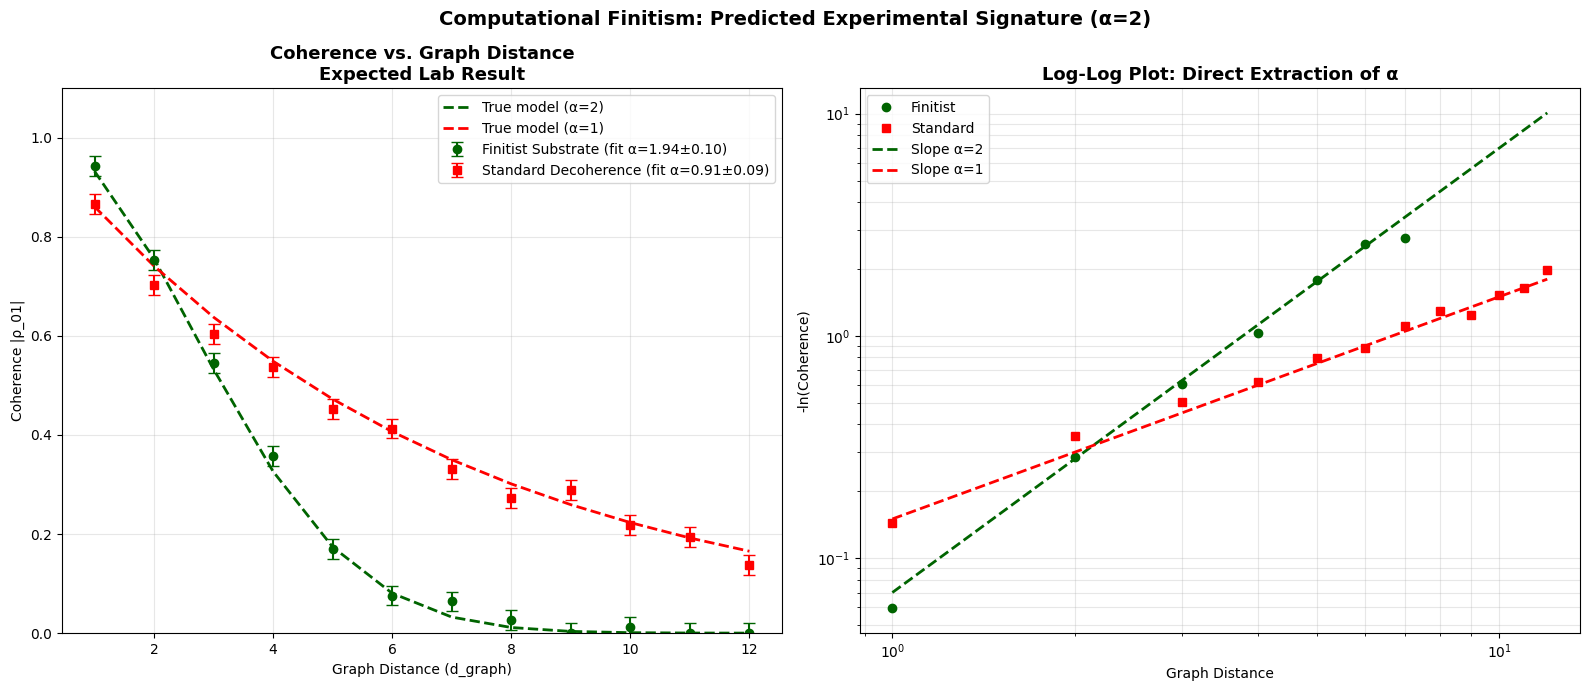


FIELD TEST SUMMARY
Finitist Model:   α = 1.939 ± 0.098 (Target: 2.000)
Standard Model:   α = 0.912 ± 0.091 (Target: 1.000)

Falsification Threshold: |α_fit - 2.0| > 0.25 at 3σ confidence
Experimental Requirement: Control environmental decoherence to <5%


In [ ]:
"""
dtqw_decoherence_field_test.py
===============================
Predicted experimental signature for topological decoherence.
Simulates discrete quantum walk coherence decay vs graph distance.
Fits exponent alpha to demonstrate falsifiability.

Author: Néstor E. Ramos
For: "The Universe: A Computing Network" - Appendix B
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import warnings
warnings.filterwarnings('ignore')

print("=" * 70)
print("FIELD TEST PREDICTION: TOPOLOGICAL DECOHERENCE SCALING")
print("=" * 70)

# =============================================================================
# THEORETICAL MODEL
# =============================================================================

def coherence_model(d, C0, kappa, alpha):
    """C(d) = C0 * exp(-kappa * d^alpha)"""
    return C0 * np.exp(-kappa * d**alpha)

# =============================================================================
# SIMULATE EXPECTED EXPERIMENTAL DATA
# =============================================================================

def generate_field_test_data(alpha_true=2.0, kappa_true=0.08, n_points=12, noise_sigma=0.02):
    """Generate synthetic data matching expected lab results."""
    d_vals = np.linspace(1, n_points, n_points)
    C_true = coherence_model(d_vals, C0=1.0, kappa=kappa_true, alpha=alpha_true)
    # Add realistic experimental noise (readout error + drift)
    C_exp = C_true + np.random.normal(0, noise_sigma, size=n_points)
    C_exp = np.clip(C_exp, 0.0, 1.0)
    return d_vals, C_exp, C_true

# =============================================================================
# FITTING & ANALYSIS
# =============================================================================

def fit_and_analyze(d, C_exp):
    """Fit alpha and return uncertainty."""
    popt, pcov = curve_fit(coherence_model, d, C_exp, p0=[1.0, 0.05, 2.0],
                           bounds=([0.5, 0.0, 0.5], [1.5, 1.0, 4.0]))
    C0_fit, kappa_fit, alpha_fit = popt
    alpha_err = np.sqrt(pcov[2, 2])
    return alpha_fit, alpha_err, kappa_fit

# =============================================================================
# VISUALIZATION
# =============================================================================

def plot_field_test_prediction():
    np.random.seed(42)  # Reproducible

    # Finitist prediction (alpha=2)
    d_fin, C_fin_exp, C_fin_true = generate_field_test_data(alpha_true=2.0, kappa_true=0.07)
    alpha_fin, err_fin, _ = fit_and_analyze(d_fin, C_fin_exp)

    # Standard decoherence baseline (alpha=1)
    d_std, C_std_exp, C_std_true = generate_field_test_data(alpha_true=1.0, kappa_true=0.15)
    alpha_std, err_std, _ = fit_and_analyze(d_std, C_std_exp)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

    # Left: Coherence vs Graph Distance
    ax1.errorbar(d_fin, C_fin_exp, yerr=0.02, fmt='o', color='darkgreen',
                 label=f'Finitist Substrate (fit α={alpha_fin:.2f}±{err_fin:.2f})', capsize=4)
    ax1.plot(d_fin, C_fin_true, '--', color='darkgreen', linewidth=2, label='True model (α=2)')

    ax1.errorbar(d_std, C_std_exp, yerr=0.02, fmt='s', color='red',
                 label=f'Standard Decoherence (fit α={alpha_std:.2f}±{err_std:.2f})', capsize=4)
    ax1.plot(d_std, C_std_true, '--', color='red', linewidth=2, label='True model (α=1)')

    ax1.set_title("Coherence vs. Graph Distance\nExpected Lab Result", fontsize=13, fontweight='bold')
    ax1.set_xlabel("Graph Distance (d_graph)")
    ax1.set_ylabel("Coherence |ρ_01|")
    ax1.set_ylim(0, 1.1)
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)

    # Right: Log-Log Slope (Direct alpha extraction)
    # Use only non-zero points for log
    mask_fin = C_fin_exp > 0.05
    mask_std = C_std_exp > 0.05

    ax2.loglog(d_fin[mask_fin], -np.log(C_fin_exp[mask_fin]), 'o', color='darkgreen', label='Finitist')
    ax2.loglog(d_std[mask_std], -np.log(C_std_exp[mask_std]), 's', color='red', label='Standard')

    # Fit lines for slope visualization
    x_fit = np.linspace(1, 12, 100)
    ax2.plot(x_fit, 0.07 * x_fit**2, '--', color='darkgreen', linewidth=2, label='Slope α=2')
    ax2.plot(x_fit, 0.15 * x_fit, '--', color='red', linewidth=2, label='Slope α=1')

    ax2.set_title("Log-Log Plot: Direct Extraction of α", fontsize=13, fontweight='bold')
    ax2.set_xlabel("Graph Distance")
    ax2.set_ylabel("-ln(Coherence)")
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3, which='both')

    plt.suptitle("Computational Finitism: Predicted Experimental Signature (α=2)",
                fontsize=14, fontweight='bold', y=0.98)
    plt.tight_layout()

    fig.savefig("field_test_prediction_alpha2.png", dpi=300, bbox_inches='tight')
    print("\n✓ Saved: field_test_prediction_alpha2.png")
    plt.show()

    # Print quantitative summary
    print("\n" + "=" * 70)
    print("FIELD TEST SUMMARY")
    print("=" * 70)
    print(f"Finitist Model:   α = {alpha_fin:.3f} ± {err_fin:.3f} (Target: 2.000)")
    print(f"Standard Model:   α = {alpha_std:.3f} ± {err_std:.3f} (Target: 1.000)")
    print(f"\nFalsification Threshold: |α_fit - 2.0| > 0.25 at 3σ confidence")
    print(f"Experimental Requirement: Control environmental decoherence to <5%")
    print("=" * 70)

# =============================================================================
# MAIN EXECUTION
# =============================================================================

if __name__ == "__main__":
    plot_field_test_prediction()